<a href="https://colab.research.google.com/github/YGYerrd/Federated-Learning-Project/blob/Master/Federated_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Dependencies

In [2]:
!pip install --upgrade tensorflow
!pip install --upgrade tensorflow-federated

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.1 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have te

In [1]:
#Loading Tensorboard used for plotting graph of output
%load_ext tensorboard

In [2]:
#For collection of dataset
import collections

#For doing operations on array
import numpy as np

import tensorflow as tf
import tensorflow_federated as tff

#Hold the random value
np.random.seed(0)

ERROR:jax._src.xla_bridge:Jax plugin configuration error: Plugin module %s could not be loaded
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/xla_bridge.py", line 428, in discover_pjrt_plugins
    plugin_module = importlib.import_module(plugin_module_name)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/importlib/__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_r

# Load Dataset

In [3]:
#The EMNIST dataset is a set of handwritten character digits
emnist_train, emnist_test = tff.simulation.datasets.emnist.load_data()

#Example of Data received by a client

In [4]:
#Showing data label
example_dataset = emnist_train.create_tf_dataset_for_client(
    emnist_train.client_ids[7])

example_element = next(iter(example_dataset))

example_element['label'].numpy()

1

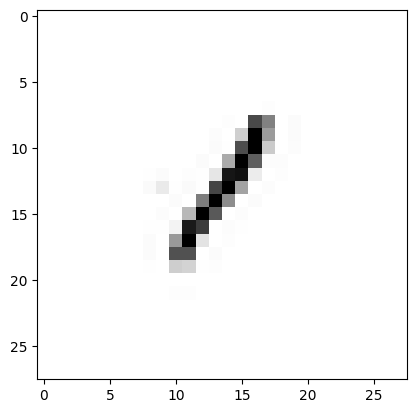

In [5]:
#Data in pixel form
from matplotlib import pyplot as plt
plt.imshow(example_element['pixels'].numpy(), cmap='gray', aspect='equal')
plt.grid(False)
_ = plt.show()

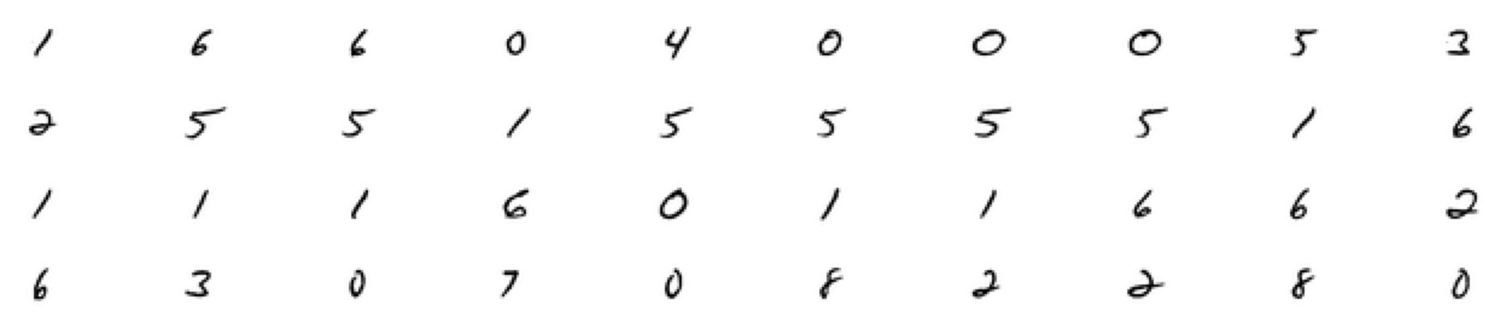

In [6]:
## Example MNIST digits for one client
figure = plt.figure(figsize=(20, 4))
j = 0

for example in example_dataset.take(40):
  plt.subplot(4, 10, j+1)
  plt.imshow(example['pixels'].numpy(), cmap='gray', aspect='equal')
  plt.axis('off')
  j += 1

# Train Client Model (Local Model)

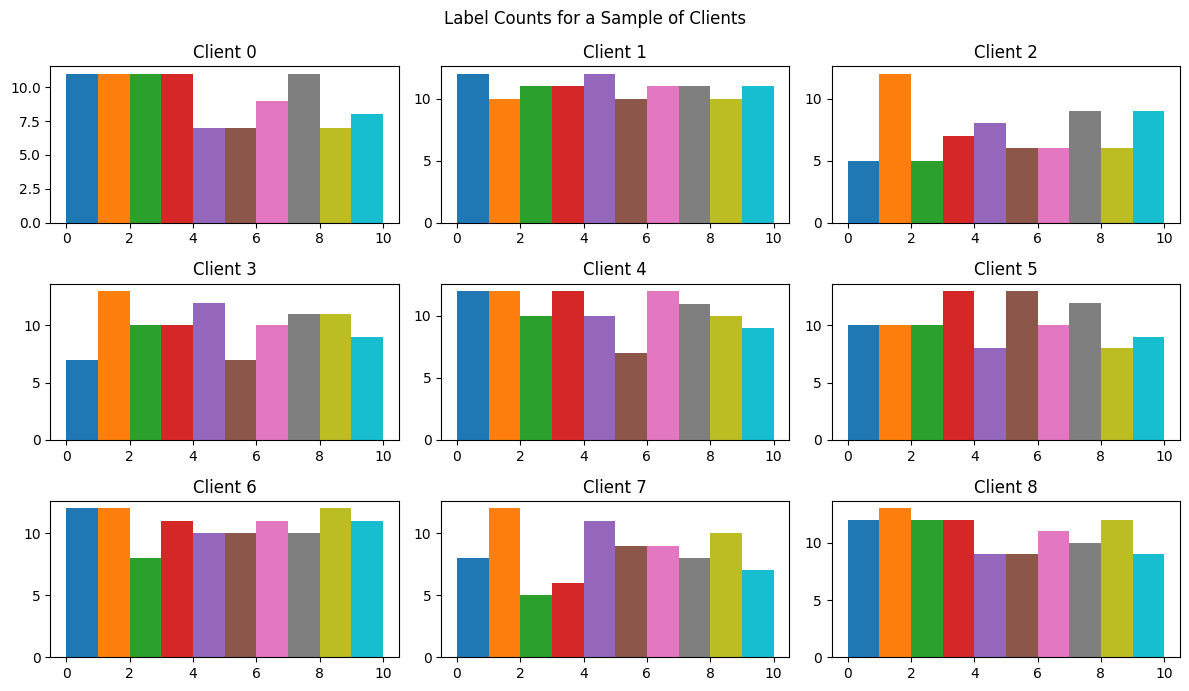

In [8]:
# Number of examples per layer for a sample of clients
f = plt.figure(figsize=(12, 7))
f.suptitle('Label Counts for a Sample of Clients')
for i in range(9):
  client_dataset = emnist_train.create_tf_dataset_for_client(
      emnist_train.client_ids[i])
  plot_data = collections.defaultdict(list)
  for example in client_dataset:
    # Append counts individually per label to make plots
    # more colorful instead of one color per plot.
    label = example['label'].numpy()
    plot_data[label].append(label)
  plt.subplot(3, 3, i+1)
  plt.title('Client {}'.format(i))
  for j in range(10):
    plt.hist(
        plot_data[j],
        density=False,
        bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    plt.tight_layout()
    # We can see data heterogeneity here

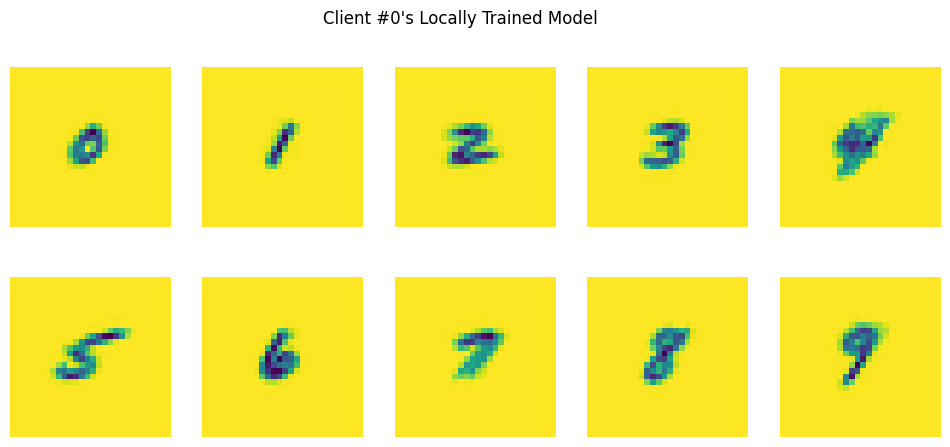

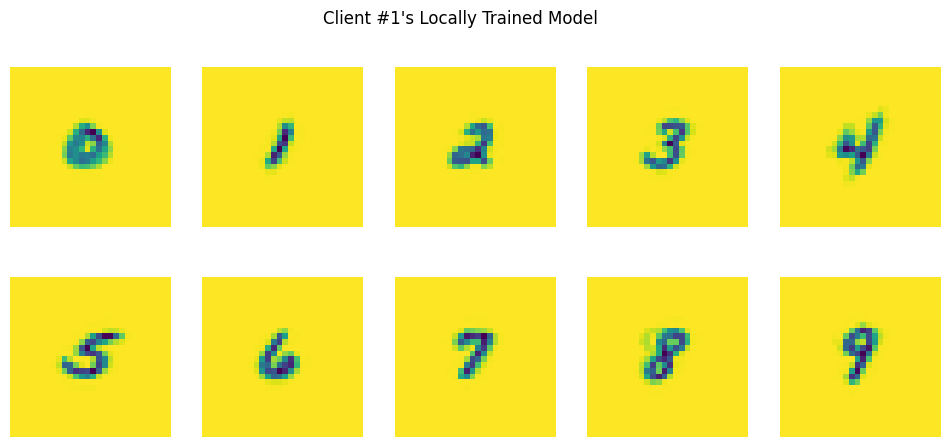

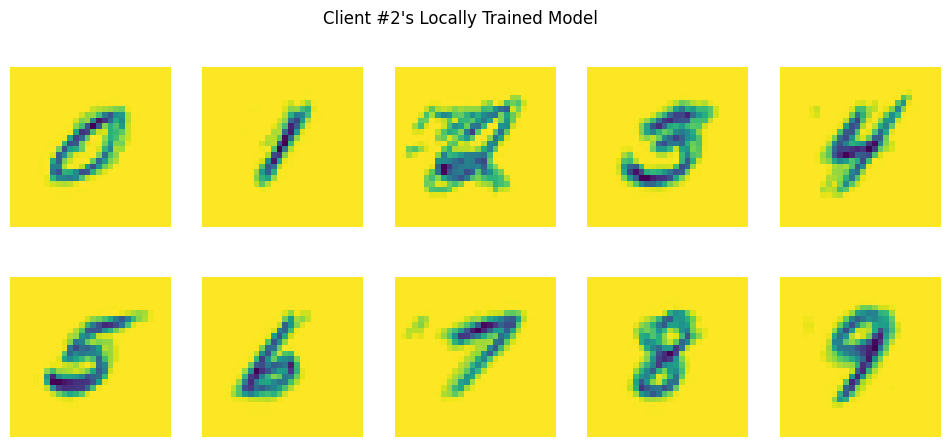

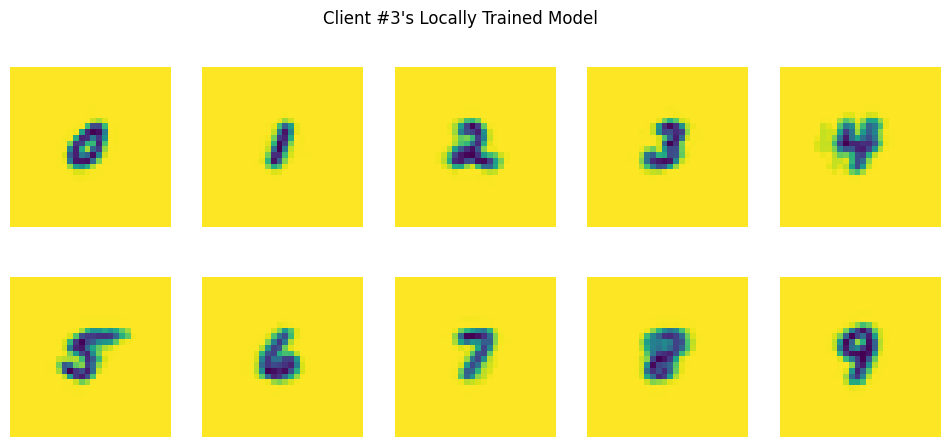

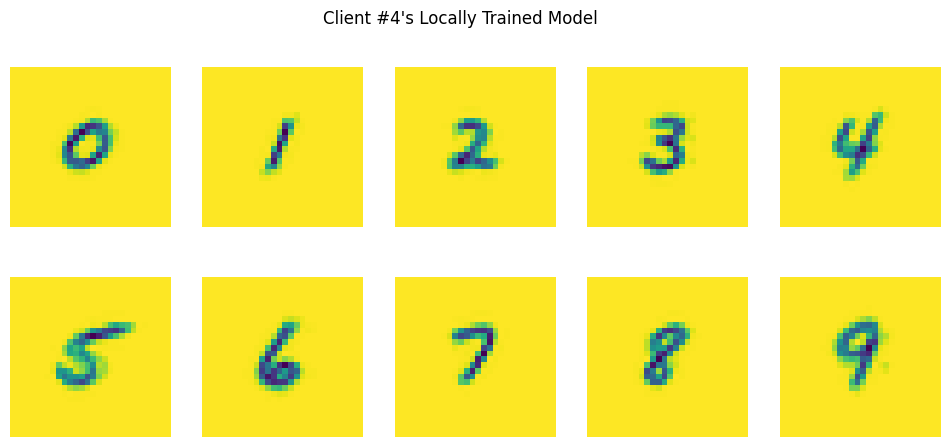

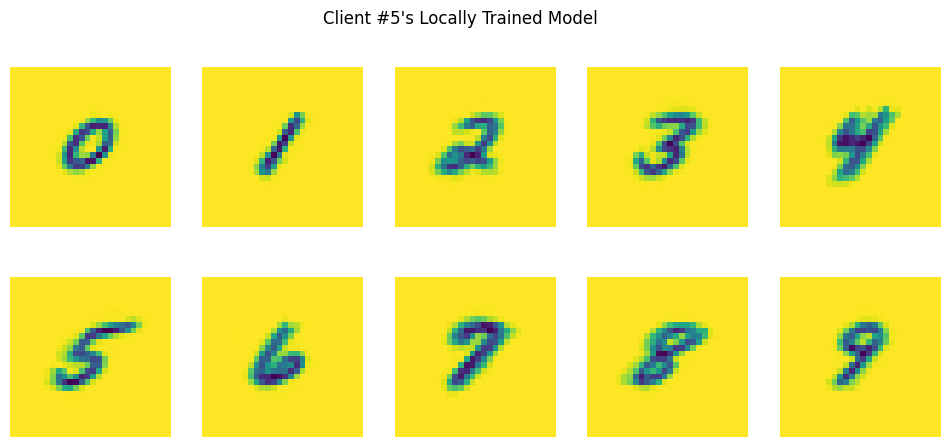

In [ ]:
# Each client has different mean images, meaning each client will be training
# the model in their own directions locally.

for i in range(6):
  client_dataset = emnist_train.create_tf_dataset_for_client(
      emnist_train.client_ids[i])
  plot_data = collections.defaultdict(list)
  for example in client_dataset:
    plot_data[example['label'].numpy()].append(example['pixels'].numpy())
  f = plt.figure(i, figsize=(12, 5))
  f.suptitle("Client #{}'s Locally Trained Model".format(i))
  for j in range(10):
    mean_img = np.mean(plot_data[j], 0)
    plt.subplot(2, 5, j+1)
    plt.imshow(mean_img.reshape((28, 28)))
    plt.axis('off')

# Preprocessing the input data

In [9]:
NUM_CLIENTS = 10
NUM_EPOCHS = 5
BATCH_SIZE = 20
# Number of training example present in single batch

SHUFFLE_BUFFER = 100
PREFETCH_BUFFER = 10
# Buffer and Prefech to spped up the process

def preprocess(dataset):

  def batch_format_fn(element):
    # We convert the 28x28 images into 784-element arrays
    # OrderDict like Order-dictionary remebers the order
    return collections.OrderedDict(
        # -1 is for "The new shape should be compatible with the original shape"
        x=tf.reshape(element['pixels'], [-1, 784]),
        y=tf.reshape(element['label'], [-1, 1]))

  return dataset.repeat(NUM_EPOCHS).shuffle(SHUFFLE_BUFFER, seed=1).batch(
      BATCH_SIZE).map(batch_format_fn).prefetch(PREFETCH_BUFFER)

In [14]:
# This data will be used while training
# Preprocess every client's data
def make_federated_data(client_data, client_ids):
  return [
      preprocess(client_data.create_tf_dataset_for_client(x))
      for x in client_ids
  ]
preprocessed_example_dataset = preprocess(example_dataset)
clients = [0, 1, 2]
sample_clients = [emnist_train.client_ids[i] for i in clients]
federated_train_data = make_federated_data(emnist_train, sample_clients)

# Creating a model with Keras

In [35]:
def create_keras_model():
  return tf.keras.models.Sequential([
      tf.keras.layers.InputLayer(input_shape=(784,), name = 'x'),
      tf.keras.layers.Dense(10, kernel_initializer='zeros'),
      # This layer applies a linear transformation to the input tensor and produces a 10-dimensional output tensor
      tf.keras.layers.Softmax(),
      #Probability distribution
  ])

In [36]:
def model_fn():
  # We creates a TFF model from a Keras model
  keras_model = create_keras_model()
  return tff.learning.models.from_keras_model(
      keras_model,
      input_spec=preprocessed_example_dataset.element_spec,
      # To calculate loss
      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
      # To calculate Accuracy
      metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])
  # We used Sparse categorical function beacuse our labels are integer

# Training the model on federated data

In [37]:
training_process = tff.learning.algorithms.build_weighted_fed_avg(
    model_fn,
    # Stochastic Gradient Descent (SGD) for optimization
    # Gradient is a rate of inclination or declination
    client_optimizer_fn=tff.learning.optimizers.build_sgdm(learning_rate=0.02),
    # smaller learning rate smaller step size
    server_optimizer_fn=tff.learning.optimizers.build_sgdm(learning_rate=1.0))

In [38]:
# To initialize Sever state
train_state = training_process.initialize()

# Result of loss and accuracy

In [41]:
def evaluate_global_model_on_clients(model_weights, client_ids, test_data_source):
    keras_model = create_keras_model()
    keras_model.compile(optimizer='sgd',
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

    model_weights.assign_weights_to(keras_model)

    for cid in client_ids:
        test_dataset = preprocess(test_data_source.create_tf_dataset_for_client(cid))

        # Unpack the batched (x, y) for evaluation
        test_dataset = test_dataset.map(lambda b: (b['x'], b['y']))  # 👈 this fixes the input issue

        loss, acc = keras_model.evaluate(test_dataset, verbose=0)
        print(f"Client {cid} — Eval of Global Model: Loss = {loss:.4f}, Accuracy = {acc:.4f}")


In [42]:
# Result in term of Matrix
result = training_process.next(train_state, federated_train_data)
train_state = result.state
train_metrics = result.metrics
NUM_ROUNDS = 20
# We run federated training process 10 times
for round_num in range(1, NUM_ROUNDS):
  result = training_process.next(train_state, federated_train_data)
  train_state = result.state
  train_metrics = result.metrics
  print('round {:2d}, metrics={}'.format(round_num, train_metrics))

  model_weights = training_process.get_model_weights(train_state)
  evaluate_global_model_on_clients(model_weights, sample_clients, emnist_test)

round  1, metrics=OrderedDict([('distributor', ()), ('client_work', OrderedDict([('train', OrderedDict([('sparse_categorical_accuracy', 0.584), ('loss', 1.2956258), ('num_examples', 1375), ('num_batches', 71)]))])), ('aggregator', OrderedDict([('mean_value', ()), ('mean_weight', ())])), ('finalizer', OrderedDict([('update_non_finite', 0)]))])
Client f0000_14 — Eval of Global Model: Loss = 1.8800, Accuracy = 0.3636
Client f0001_41 — Eval of Global Model: Loss = 1.2892, Accuracy = 0.6154
Client f0005_26 — Eval of Global Model: Loss = 2.9282, Accuracy = 0.1111
round  2, metrics=OrderedDict([('distributor', ()), ('client_work', OrderedDict([('train', OrderedDict([('sparse_categorical_accuracy', 0.60145456), ('loss', 1.2447476), ('num_examples', 1375), ('num_batches', 71)]))])), ('aggregator', OrderedDict([('mean_value', ()), ('mean_weight', ())])), ('finalizer', OrderedDict([('update_non_finite', 0)]))])
Client f0000_14 — Eval of Global Model: Loss = 1.8090, Accuracy = 0.3636
Client f0001_

In [ ]:
# Displaying Result in form of Graph

#Creating new directory in tensorboar
logdir = "/tmp/logs/scalars/training/"
try:
  tf.io.gfile.rmtree(logdir)  # delete any previous results
except tf.errors.NotFoundError as e:
  pass # Ignore if the directory didn't previously exist.
summary_writer = tf.summary.create_file_writer(logdir)
#train_state = training_process.initialize()

with summary_writer.as_default():
  for round_num in range(1, NUM_ROUNDS):
    result = training_process.next(train_state, federated_train_data)
    train_state = result.state
    train_metrics = result.metrics
    for name, value in train_metrics['client_work']['train'].items():
      tf.summary.scalar(name, value, step=round_num)

!ls {logdir}
%tensorboard --logdir {logdir} --port=0